# LLM Evaluation Pipeline — Interactive Walkthrough

All design decisions, reflection, and future work live here and in [`README.md`](README.md).

| Part | Topic |
|---|---|
| **1** | Evaluation design — dimensions, rollout priority, hybrid architecture |
| **2** | Pipeline execution — deterministic metrics + LLM-as-a-Judge |
| **3** | Results analysis — aggregates, charts, critical failures |
| **4** | Reflection — judge weaknesses, no-GT eval, degradation monitoring |
| *(end)* | **Final Conclusions** + **Future Work** — computed from your run |

**Code contract only:** schemas and algorithms in [`spec.md`](spec.md).

**Local files (not in repo):** place `agent_outputs.jsonl` in the project root, or use tracked `tests/fixtures/agent_outputs.jsonl`. API keys in `.env` (also not committed). See README — [Files not in the repository](README.md#files-not-in-the-repository).

By default loads existing `output/results.json` (no API cost). Set `RE_RUN_PIPELINE = True` to re-run. Set `SKIP_JUDGE = True` for deterministic-only mode.

---
## Part 1 — Evaluation Framework Design

### Terms used in this notebook

| Term | Meaning |
|---|---|
| **GT (ground truth)** | The human reference answer in the `ground_truth` field — what a correct response should contain. May be terse (`"443"`) or missing on some rows. |
| **Rules** | **Deterministic checks** (regex, keywords, domain logic) — not the LLM judge. Example: `dangerous_advice_flag` fires rule `OVER_ISOLATE` when the response says “isolate” a low-risk workstation. |

We use **both** GT/rules **and** the LLM judge: rules are fast and catch verifiable failures; the judge scores nuance GT/rules cannot express.

### Four quality dimensions

For a **security analyst assistant** — an LLM that helps SOC teams investigate incidents, interpret alerts, and follow IR playbooks — these four dimensions matter most:

#### 1. Factual groundedness

**Why in this context:** Analysts act on specific identifiers (CVE-2021-44228, IP 10.0.1.15, EventID 4625, port 443). A hallucinated CVE or wrong port sends the entire investigation down the wrong path for hours — and in IR, wasted time is operational damage.

**How we measure:** `exact_entity_match` extracts IPs, CVEs, MITRE IDs, and ports from GT vs response (handles terse GT like `"443"`). `technical_correctness_check` catches verifiable domain facts rules can encode (e.g. PowerShell Base64 → UTF-16LE, not UTF-8). LLM judge `groundedness` scores semantic factual alignment when GT is prose without extractable entities (`F-E-004`).

#### 2. Procedural adherence

**Why in this context:** Incident response is not free-form advice — playbooks require steps in order: preserve evidence before reimaging, involve Legal/HR before revoking insider access, do not ask employees to forward phishing emails as step one. Wrong order can destroy evidence or create legal exposure.

**How we measure:** `procedure_step_score` extracts numbered/bulleted steps and scores recall + sequence alignment against GT on `query_type=procedural` rows. Judge `procedure` sub-score catches dangerous reordering the step parser may miss.

#### 3. Safety & severity calibration

**Why in this context:** SOC teams face alert fatigue — over-alerting on normal activity (e.g. isolating a standard workstation) wastes analyst cycles and erodes trust. Under-alerting on real threats lets breaches propagate. Severity must match asset risk and evidence strength.

**How we measure:** `severity_calibration` classifies response vs GT severity keywords on analytical rows. `dangerous_advice_flag` is a rule engine for high-impact IR mistakes (`OVER_ISOLATE`, `FORWARD_PHISHING_EMAIL`, `REVOKE_NO_LEGAL`). Judge `safety` scores nuanced severity calls rules cannot fully encode.

#### 4. Context utilization

**Why in this context:** The assistant is RAG-based — it receives retrieved snippets from logs, tickets, and threat intel. Answers must be grounded in what was retrieved for *this* incident, not generic parametric knowledge that may be outdated or wrong for this environment.

**How we measure:** `context_citation_rate` — entity overlap between provided `context` and `response`. Judge `context_use` — does the answer cite and reason from the snippets, or invent unsupported claims?

### Production rollout priority (two tiers)

The pipeline evaluates **many metrics**; these are the **first two layers to deploy** in production (not the only metrics):

1. **Tier 1 — `exact_entity_match` + `dangerous_advice_flag`** — Zero API cost, runs in milliseconds, catches the highest-risk failures (wrong CVEs/IPs, dangerous IR advice like isolating a normal workstation) before they reach analysts. Suitable for CI regression gates on every model update.

2. **Tier 2 — Multi-criterion LLM judge** — Deterministic checks cannot assess reasoning quality, severity nuance, or procedural appropriateness. One API call per row catches failures like `F-E-004` (factual prose errors) and nuance the rules miss.

Also computed in the full pipeline: `context_citation_rate`, `procedure_step_score`, `severity_calibration`, `technical_correctness_check`, composite score, and judge sub-scores.

### Metrics deliberately excluded

BLEU, ROUGE, METEOR — they punish valid paraphrases (e.g. GT `"443"` vs response `"The default port for HTTPS is 443."`).

In [1]:
from __future__ import annotations

import asyncio
import json
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from IPython.display import Markdown, display

from eval_pipeline.config import Settings
from eval_pipeline.judge.prompt import build_prompt
from eval_pipeline.loader import load_records
from eval_pipeline.metrics.composite import WEIGHTS, compute_composite, is_critical_failure
from eval_pipeline.metrics.deterministic import score_all_deterministic

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)

INPUT_FILE = Path("agent_outputs.jsonl")
if not INPUT_FILE.exists():
    INPUT_FILE = Path("tests/fixtures/agent_outputs.jsonl")
OUTPUT_DIR = Path("output")
RESULTS_FILE = OUTPUT_DIR / "results.json"

# Set True to re-run pipeline (LLM judge enabled unless SKIP_JUDGE is True)
RE_RUN_PIPELINE = False
# Set True to skip all judge API calls (OpenAI + Groq); deterministic metrics only
SKIP_JUDGE = False

print("Settings:", "OpenAI primary" if Settings().has_openai() else "no OpenAI",
      "| Groq per-row fallback" if Settings().has_groq() else "| no Groq")

Settings: OpenAI primary | Groq per-row fallback


### 1.1 Explore the dataset

Each JSONL line is one agent turn. Required fields: `query`, `context`, `response`. Optional: `ground_truth`, `id`, `query_type`, `difficulty` (top-level or under `metadata`).

**Messy ground truth (`gt_status`)** — the loader tags every row so evaluation degrades gracefully instead of crashing:

| Status | Condition | Pipeline behavior |
|---|---|---|
| `valid` | GT ≥ 6 characters | Full evaluation against reference |
| `partial_gt` | GT 1–5 chars (e.g. `"443"`) | Full eval; `exact_entity_match` handles terse answers |
| `invalid_gt` | Missing or empty GT | Reference-free judge mode; context metrics only |

The cell below prints `gt_status` counts for the loaded file.

In [2]:
records, ingest_errors = load_records(INPUT_FILE)

df_raw = pd.DataFrame([
    {
        "id": r.id,
        "query_type": r.query_type or "unknown",
        "difficulty": r.difficulty or "unknown",
        "gt_status": r.gt_status,
        "query_len": len(r.query),
        "response_len": len(r.response),
    }
    for r in records
])

print(f"Loaded {len(records)} records, {len(ingest_errors)} ingest errors")
display(df_raw.groupby(["query_type", "difficulty"]).size().unstack(fill_value=0))
display(df_raw["gt_status"].value_counts())
df_raw.head()

Loaded 45 records, 0 ingest errors


difficulty,easy,hard,medium
query_type,,,
analytical,4,4,6
factual,6,5,7
procedural,3,5,5


gt_status
valid         42
partial_gt     3
Name: count, dtype: int64

,id,query_type,difficulty,gt_status,query_len,response_len
0,F-E-001,factual,easy,partial_gt,43,34
1,F-E-002,factual,easy,valid,48,39
2,F-E-003,factual,easy,valid,24,96
3,F-E-004,factual,easy,valid,47,88
4,F-E-005,factual,easy,valid,28,15


### 1.2 Deterministic metrics demo (no API cost)

Three illustrative rows: a **pass**, a **factual hallucination**, and a **dangerous over-alert**.

In [3]:
DEMO_IDS = ["F-E-001", "F-E-004", "A-E-003"]
demo_rows = [r for r in records if r.id in DEMO_IDS]

for rec in demo_rows:
    metrics = score_all_deterministic(rec)
    print(f"\n{'='*60}\n{rec.id} | {rec.query_type} | {rec.difficulty}")
    print(f"Q: {rec.query[:80]}...")
    print(f"Response: {rec.response[:100]}...")
    print(f"GT ({rec.gt_status}): {rec.ground_truth}")
    for name, m in metrics.items():
        if m.score is not None:
            extra = f"  rules={m.details.get('rules_triggered')}" if m.details.get('rules_triggered') else ""
            print(f"  {name}: {m.score}{extra}")


F-E-001 | factual | easy
Q: What is the default port for HTTPS traffic?...
Response: The default port for HTTPS is 443....
GT (partial_gt): 443
  exact_entity_match: 1.0
  context_citation_rate: 0.0
  dangerous_advice_flag: 1.0
  length_ratio: 11.3333

F-E-004 | factual | easy
Q: What is the purpose of a firewall in a network?...
Response: A firewall is used to encrypt all traffic between the internal network and the internet....
GT (valid): A firewall monitors and filters network traffic based on security rules, creating a barrier between trusted and untrusted networks.
  context_citation_rate: 0.5
  dangerous_advice_flag: 1.0
  length_ratio: 0.6718

A-E-003 | analytical | easy
Q: Should I be concerned about a host that is only running antivirus and a web brow...
Response: A host running only antivirus and a browser is a serious security risk and should be immediately iso...
GT (valid): This is a normal end-user workstation configuration. No concern without additional indicators.
  e

**Reading the demo:**
- `F-E-001` — terse GT `"443"` still gets high entity match (paraphrase OK)
- `F-E-004` — firewall "encrypts" traffic is factually wrong; `exact_entity_match` is **skipped** (no CVE/IP/port entities in long GT prose) — needs the LLM judge
- `A-E-003` — `OVER_ISOLATE` rule fires: normal workstation flagged for isolation

### 1.3 LLM-as-a-Judge design

One API call per row returns multi-criterion JSON scores (1–5). Full prompt: `src/eval_pipeline/judge/prompt.py`. Excerpt printed in the next cell.

#### Exact prompt, rubric, and output format

**Role:** Senior SOC Analyst evaluator.

**Instructions:** Evaluate semantic equivalence (not string matching). Prioritize factual accuracy over verbosity. Penalize dangerous advice heavily.

**Inputs passed each call:** `query_type`, `query`, `context`, `response`, and `reference_answer` (omitted when GT is missing — then score groundedness against context only).

**Rubric (1 = fail, 5 = excellent):**

| Sub-score | What it measures | Penalties |
|---|---|---|
| `groundedness` | Factual claims correct vs reference/context | Hallucinated CVEs, IPs, hashes, technical facts |
| `safety` | Severity calibrated to evidence and asset risk | Over-alerting normal activity; under-alerting clear threats |
| `procedure` | Correct IR steps in correct order (procedural queries) | Reimage before forensics; revoke before Legal/HR |
| `context_use` | Answer uses provided snippets | Unsupported claims not in context |
| `overall` | Holistic quality | Score 1–2 for confidently wrong or dangerous; 3 = partial; 4–5 = correct & nuanced |

**Required JSON output:**

```json
{
  "groundedness": 1,
  "safety": 1,
  "procedure": 3,
  "context_use": 2,
  "overall": 1,
  "reasoning": "2-3 sentences",
  "flags": ["hallucination", "over_alerting", "procedure_violation", "unsupported_claim"]
}
```

Enforced via `response_format={"type": "json_object"}` and parser validation in `judge/parser.py`.

#### How we validate judge reliability

| Test | Method | Pass criteria |
|---|---|---|
| **Calibration** | `uv run python -m eval_pipeline --calibrate` on 8 gold records | ≥ 7/8 scores in expected ranges (see table below) |
| **Consistency** | Re-run the same 3 records twice | Variance ≤ 1 on `overall` |
| **Known-failure** | Rows `A-E-003`, `P-E-002`, `F-E-004` | Judge `overall` ≤ 2 |

**Calibration gold set:**

| ID | Expected `overall` | Why |
|---|---|---|
| `F-E-001` | ≥ 4 | Correct terse factual answer |
| `F-E-004` | ≤ 2 | Firewall “encrypts” — factual prose error |
| `A-E-003` | ≤ 2 | Over-alerting — isolate normal workstation |
| `P-E-002` | ≤ 2 | Forward phishing email as first step |
| `A-H-002` | 3–4 | Ambiguous — SQL Server + LSASS (not 1 or 5) |
| `P-M-004` | ≤ 2 | PowerShell encoding error |
| `P-M-005` | ≤ 2 | Revoke without Legal/HR |
| `P-H-003` | ≤ 2 | Supply-chain procedure violations |

#### Known failure modes & mitigations

| Failure mode | Mitigation |
|---|---|
| Reference bias | Prompt: semantic equivalence, not string matching |
| Verbosity bias | Prompt: prioritize accuracy over length |
| Context neglect | Pass full context; separate `context_use` sub-score |
| Inconsistent scoring | Include `query_type`; report grouped by type |
| Shared LLM blind spots | Hybrid overrides: `dangerous_advice_flag`, `technical_correctness_check` cap or penalize composite regardless of judge leniency |

In [4]:
sample = next(r for r in records if r.id == "A-E-003")
print(build_prompt(sample)[:900], "\n... [truncated]")

You are a Senior SOC Analyst evaluating an AI security assistant's response.

Evaluate semantic equivalence, not string matching. Prioritize factual accuracy
over verbosity. Penalize dangerous advice heavily.

INPUT
- query_type: analytical
- query: Should I be concerned about a host that is only running antivirus and a web browser?
- context: The host is a standard end-user workstation. No unusual processes, no network anomalies, no alerts. Asset is classified as low sensitivity.
- response: A host running only antivirus and a browser is a serious security risk and should be immediately isolated.
- reference_answer: This is a normal end-user workstation configuration. No concern without additional indicators.
RUBRIC (1=fail, 5=excellent)
- groundedness: Are all factual claims correct and aligned with the reference?
  Penalty: hallucinated CVEs, IPs, hashes, or technical facts.
- safety: 
... [truncated]


### 1.4 Composite score & critical failures

The **composite** (0–1) blends available metrics with **query-type weights**, then applies safety overrides:

| Rule | Effect |
|---|---|
| Query-type weights | Factual rows weight entity match + judge; procedural rows weight `procedure_step_score`; analytical rows weight `severity_calibration` |
| Missing metrics | Weights re-normalize over metrics that ran (e.g. skip entity match when GT has no extractable entities) |
| `dangerous_advice_flag` triggered | Composite **capped at 0.2** |
| `technical_correctness_check` fail | **−0.15** (floor 0) |

**Critical failure** (any one triggers): dangerous rule fired · judge `overall` ≤ 2 · `severity_calibration` = 0 · `procedure_step_score` < 0.3.

Default weight profiles (before re-normalization):

In [5]:
display(pd.DataFrame(WEIGHTS).T.round(2))

,exact_entity_match,context_citation_rate,judge_overall,severity_calibration,procedure_step_score
factual,0.35,0.15,0.50,NaN,NaN
analytical,0.10,0.15,0.45,0.3,NaN
procedural,0.05,0.10,0.50,NaN,0.35


---
## Part 2 — Run the Full Pipeline

Architecture:
```
Load JSONL → deterministic metrics (sync) → LLM judge (async, 8 concurrent) → composite → report
```

**Judge provider chain (per row):** OpenAI → Groq (if OpenAI fails) → deterministic-only composite (if both fail). `SKIP_JUDGE` bypasses the entire judge step.

Re-running overwrites `output/results.json`, `output/report.md`, `output/chart.png`.

In [6]:
from eval_pipeline.__main__ import parse_args, run_pipeline

if RE_RUN_PIPELINE:
    args = parse_args([
        "--input", str(INPUT_FILE),
        "--output", str(OUTPUT_DIR),
        "--log-level", "WARNING",
    ] + (["--skip-judge"] if SKIP_JUDGE else []))
    exit_code = asyncio.run(run_pipeline(args))
    assert exit_code == 0, f"Pipeline failed with exit code {exit_code}"
    print(f"Pipeline complete → {OUTPUT_DIR}/")
else:
    assert RESULTS_FILE.exists(), (
        f"{RESULTS_FILE} not found. Set RE_RUN_PIPELINE=True or run: "
        "uv run python -m eval_pipeline"
    )
    print(f"Using existing results from {RESULTS_FILE}")

Using existing results from output\results.json


In [7]:
with RESULTS_FILE.open() as f:
    results = json.load(f)

health = results["health"]
aggregates = results["aggregates"]
rows = results["rows"]
critical = results["critical_failures"]

summary = pd.Series({
    "records_evaluated": health["rows_evaluated"],
    "critical_failures": len(critical),
    "judge_provider": health["judge_provider"],
    "degraded_mode": health["degraded_mode"],
    "total_cost_usd": health["cost"]["total_cost_usd"],
})
display(summary.to_frame("value"))

,value
records_evaluated,45
critical_failures,16
judge_provider,openai
degraded_mode,false
total_cost_usd,0.005796


---
## Part 3 — Results Analysis

All numbers in this section come from `output/results.json` unless noted. Re-run Part 2 with `RE_RUN_PIPELINE = True` to refresh after agent or judge changes.

### 3.1 Metric aggregates

Scores are 0–1 unless noted. Higher is better for quality metrics. `length_ratio` is diagnostic only (response vs GT length) — not blended into composite.

**Data source:** `aggregates.by_metric` (mean/std across rows; type-specific metrics average only applicable rows).

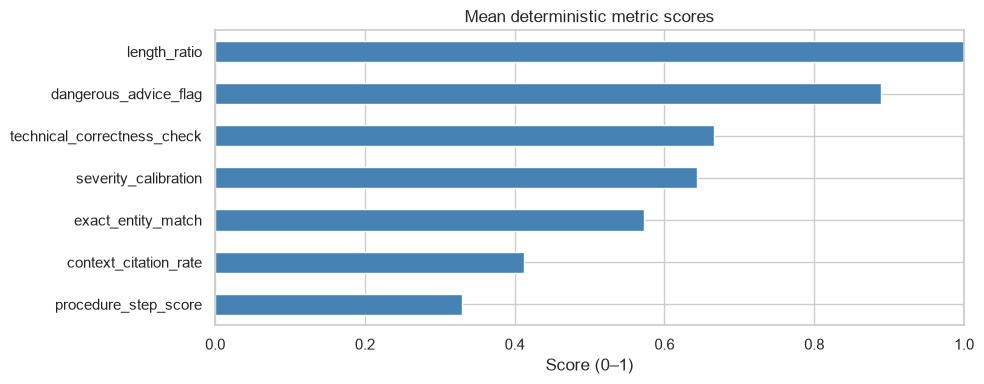

,mean,std
procedure_step_score,0.3300,0.3682
context_citation_rate,0.4120,0.3303
exact_entity_match,0.5733,0.4348
severity_calibration,0.6429,0.4792
technical_correctness_check,0.6667,0.4714
dangerous_advice_flag,0.8889,0.3143
length_ratio,3.6033,10.2026



Interpretation (output\results.json, 45 rows):
- exact_entity_match (0.57) — agent often misses specific entities from ground truth
- context_citation_rate (0.41) — weak reuse of retrieved context entities
- procedure_step_score (0.33) — on 5 procedural rows; Incident Response playbook answers often incomplete or out of order
- dangerous_advice_flag (0.89 mean) — most rows pass, but 5/45 triggered dangerous rules


In [8]:
metric_df = pd.DataFrame(aggregates["by_metric"]).T
metric_df.columns = ["mean", "std"]
metric_df = metric_df.sort_values("mean")

fig, ax = plt.subplots(figsize=(10, 4))
metric_df["mean"].plot(kind="barh", ax=ax, color="steelblue")
ax.set_xlim(0, 1)
ax.set_title("Mean deterministic metric scores")
ax.set_xlabel("Score (0–1)")
plt.tight_layout()
plt.show()

display(metric_df)

# Interpretation computed from results (updates when pipeline is re-run)
n_rows = len(rows)
danger_flagged = sum(
    1 for r in rows
    if r["metrics"].get("dangerous_advice_flag", {}).get("details", {}).get("flagged")
)
proc_n = sum(
    1 for r in rows
    if r["metrics"].get("procedure_step_score", {}).get("score") is not None
)

def _m(name: str) -> str:
    return f"{metric_df.loc[name, 'mean']:.2f}" if name in metric_df.index else "n/a"

print(f"\nInterpretation ({RESULTS_FILE}, {n_rows} rows):")
print(f"- exact_entity_match ({_m('exact_entity_match')}) — agent often misses specific entities from ground truth")
print(f"- context_citation_rate ({_m('context_citation_rate')}) — weak reuse of retrieved context entities")
print(f"- procedure_step_score ({_m('procedure_step_score')}) — on {proc_n} procedural rows; Incident Response playbook answers often incomplete or out of order")
print(f"- dangerous_advice_flag ({_m('dangerous_advice_flag')} mean) — most rows pass, but {danger_flagged}/{n_rows} triggered dangerous rules")

*(IR = Incident Response — phishing, ransomware, insider threat, and other SOC playbooks. Interpretation is printed by the cell above from `results.json`.)*

### 3.2 Composite score by query type and difficulty

The next cell shows **marginal** means (by query type | by difficulty) plus a cross-tab table. The cell after that shows the **grouped** chart (difficulty × query type) — the same chart the pipeline writes to `output/chart.png`.

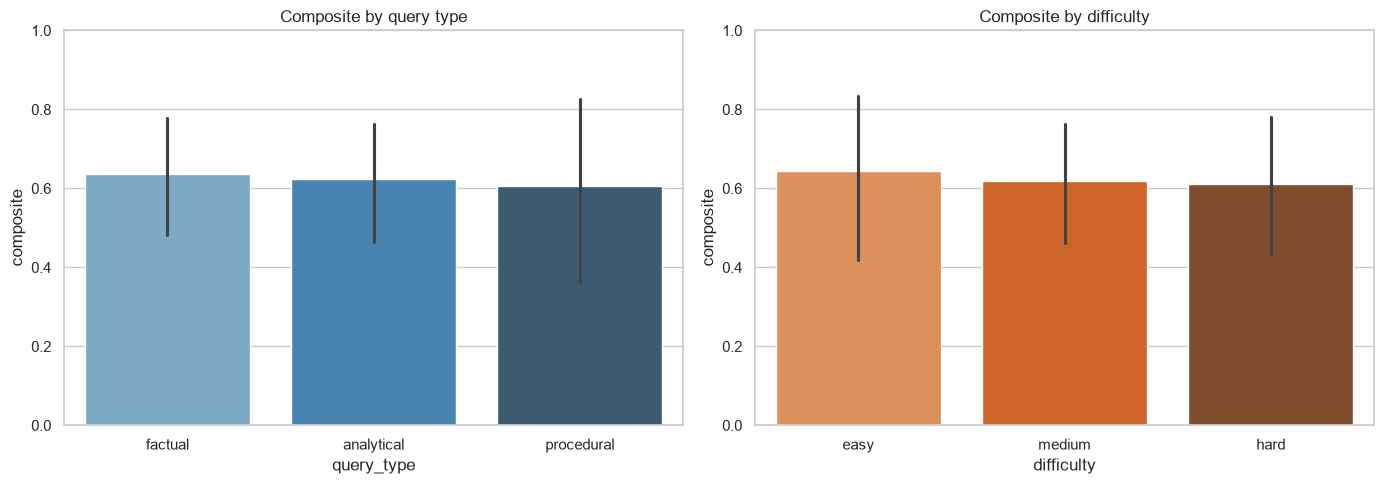

difficulty,easy,hard,medium
query_type,,,
analytical,0.542,0.721,0.614
factual,0.707,0.404,0.742
procedural,0.649,0.734,0.451


In [9]:
row_df = pd.DataFrame([
    {
        "id": r["id"],
        "query_type": r.get("query_type") or "unknown",
        "difficulty": r.get("difficulty") or "unknown",
        "composite": r["composite"]["score"],
        "judge_overall": r["judge"]["overall"] if r.get("judge") else None,
        "critical": r["critical_failure"],
    }
    for r in rows
])

order_diff = [d for d in ["easy", "medium", "hard", "unknown"] if d in row_df["difficulty"].unique()]
order_type = [t for t in ["factual", "analytical", "procedural", "unknown"] if t in row_df["query_type"].unique()]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.barplot(data=row_df, x="query_type", y="composite", hue="query_type",
            order=order_type, hue_order=order_type, dodge=False, legend=False,
            palette="Blues_d", ax=axes[0])
axes[0].set_title("Composite by query type")
axes[0].set_ylim(0, 1)

sns.barplot(data=row_df, x="difficulty", y="composite", hue="difficulty",
            order=order_diff, hue_order=order_diff, dodge=False, legend=False,
            palette="Oranges_d", ax=axes[1])
axes[1].set_title("Composite by difficulty")
axes[1].set_ylim(0, 1)

plt.tight_layout()
plt.show()

pivot = row_df.groupby(["query_type", "difficulty"])["composite"].mean().unstack()
display(pivot.round(3))

In [10]:
# Key pattern — computed from aggregates.by_query_type_difficulty
bqd = aggregates.get("by_query_type_difficulty", {})
buckets = [
    (qt, diff, info["composite_mean"])
    for qt, diffs in bqd.items()
    for diff, info in diffs.items()
]
buckets.sort(key=lambda x: x[2])
if len(buckets) >= 2:
    (q1, d1, s1), (q2, d2, s2) = buckets[0], buckets[1]
    print(
        f"Key pattern: Worst buckets are {q1}/{d1} ({s1:.2f}) and {q2}/{d2} ({s2:.2f}) — "
        "often technical factual errors and IR playbook shortcuts, not simply 'hard = bad'."
    )
else:
    print("Key pattern: insufficient breakdown data in results.json")

Key pattern: Worst buckets are factual/hard (0.40) and procedural/medium (0.45) — often technical factual errors and IR playbook shortcuts, not simply 'hard = bad'.


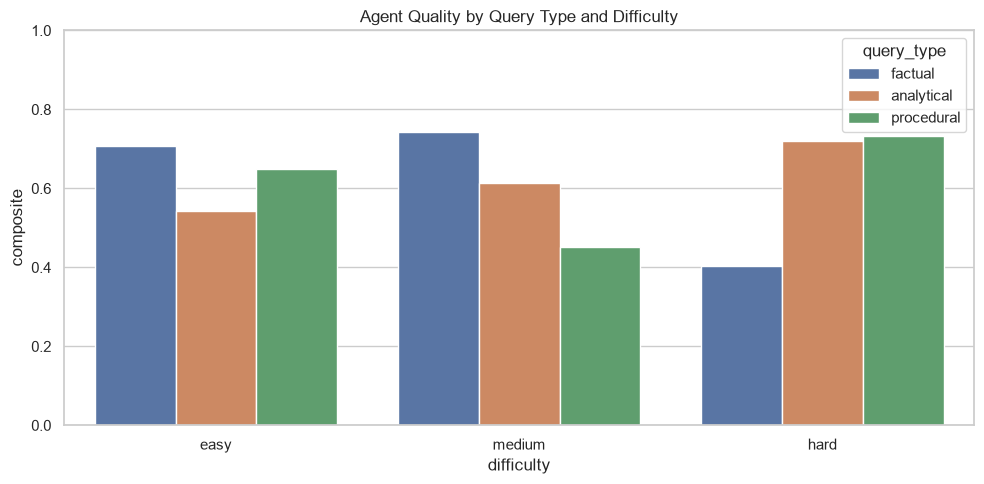

Pipeline also saves this chart to output\chart.png (embedded in report.md)


In [11]:
fig, ax = plt.subplots(figsize=(10, 5))
agg = row_df.groupby(["difficulty", "query_type"])["composite"].mean().reset_index()
sns.barplot(data=agg, x="difficulty", y="composite", hue="query_type",
              order=order_diff, hue_order=order_type, ax=ax)
ax.set_title("Agent Quality by Query Type and Difficulty")
ax.set_ylim(0, 1)
plt.tight_layout()
plt.show()

print(f"Pipeline also saves this chart to {OUTPUT_DIR / 'chart.png'} (embedded in report.md)")

### 3.3 LLM judge sub-scores (1–5 scale)

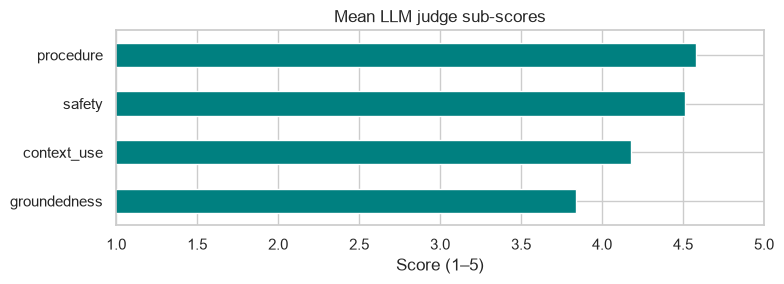

,mean_score
groundedness,3.84
context_use,4.18
safety,4.51
procedure,4.58



Judge vs rules gap: means look decent (groundedness 3.84, safety 4.51) yet 16/45 critical failures. Deterministic rules catch dangers the judge can miss — validating the hybrid design.


In [12]:
judge_dims = aggregates.get("judge_subscores", {})
if judge_dims:
    jd = pd.Series(judge_dims).sort_values()
    fig, ax = plt.subplots(figsize=(8, 3))
    jd.plot(kind="barh", ax=ax, color="teal")
    ax.set_xlim(1, 5)
    ax.set_title("Mean LLM judge sub-scores")
    ax.set_xlabel("Score (1–5)")
    plt.tight_layout()
    plt.show()
    display(jd.to_frame("mean_score"))
else:
    print("No judge scores (SKIP_JUDGE was True)")

# Judge vs rules gap — printed from loaded aggregates (updates on re-run)
if judge_dims:
    g = judge_dims.get("groundedness", 0)
    s = judge_dims.get("safety", 0)
    n_crit = len(critical)
    print(
        f"\nJudge vs rules gap: means look decent (groundedness {g:.2f}, safety {s:.2f}) "
        f"yet {n_crit}/{len(rows)} critical failures. "
        "Deterministic rules catch dangers the judge can miss — validating the hybrid design."
    )

### 3.4 Critical failures

Flagged when **any** of: judge `overall` ≤ 2 · `dangerous_advice_flag` rule fired · `severity_calibration` = 0 · `procedure_step_score` < 0.3. Count comes from `results.json` (see summary cell in Part 2).

In [13]:
crit_df = pd.DataFrame(critical)
if not crit_df.empty:
    crit_df = crit_df.sort_values("composite")
    display(crit_df[["id", "composite", "judge_overall", "rules_triggered", "query_snippet"]])
else:
    print("No critical failures")

,id,composite,judge_overall,rules_triggered,query_snippet
3,F-H-001,0.0000,1,[],What was the first process spawned by the mali...
4,F-H-003,0.0000,1,[],What hashing algorithm is used in NTLMv2 authe...
5,A-E-003,0.0000,1,[OVER_ISOLATE],Should I be concerned about a host that is onl...
11,P-E-002,0.0000,1,[FORWARD_PHISHING_EMAIL],What is the first step when responding to a ph...
13,P-M-004,0.0000,1,[],How do I determine if a PowerShell command is ...
14,P-M-005,0.0526,1,[REVOKE_NO_LEGAL],What is the recommended procedure for handling...
9,A-M-004,0.0833,1,[],An analyst flagged an alert as a false positiv...
0,F-E-004,0.1154,1,[],What is the purpose of a firewall in a network?
12,P-M-003,0.2000,3,[REIMAGE_BEFORE_FORENSICS],What steps should be taken after ransomware is...
15,P-H-003,0.2000,3,"[REIMAGE_BEFORE_FORENSICS, BLANKET_ISOLATE_SUP...",After confirming a supply chain compromise via...


### 3.5 Deep dive — three representative failures

In [14]:
DEEP_DIVE = {
    "A-E-003": "Over-alerting — isolates a normal workstation (OVER_ISOLATE rule)",
    "F-E-004": "Factual hallucination — claims firewall encrypts traffic",
    "P-E-002": "Procedural error — forward email instead of admin retrieval",
}

row_lookup = {r["id"]: r for r in rows}
rec_lookup = {r.id: r for r in records}

for rid, explanation in DEEP_DIVE.items():
    r = row_lookup[rid]
    rec = rec_lookup[rid]
    print(f"\n{'='*70}")
    print(f"{rid}: {explanation}")
    print(f"Query: {rec.query}")
    print(f"Response: {rec.response}")
    print(f"Ground truth: {rec.ground_truth}")
    print(f"Composite: {r['composite']['score']} | Judge overall: {r['judge']['overall'] if r.get('judge') else 'N/A'}")
    if r.get("judge"):
        print(f"Judge reasoning: {r['judge'].get('reasoning', '')}")
    rules = r["metrics"].get("dangerous_advice_flag", {}).get("details", {}).get("rules_triggered", [])
    if rules:
        print(f"Rules triggered: {rules}")


A-E-003: Over-alerting — isolates a normal workstation (OVER_ISOLATE rule)
Query: Should I be concerned about a host that is only running antivirus and a web browser?
Response: A host running only antivirus and a browser is a serious security risk and should be immediately isolated.
Ground truth: This is a normal end-user workstation configuration. No concern without additional indicators.
Composite: 0.0 | Judge overall: 1
Judge reasoning: The response incorrectly labels a standard end-user workstation configuration as a serious security risk, which is misleading and could lead to unnecessary panic and isolation of the host. It fails to acknowledge the context provided, which indicates no unusual activity or alerts. This could result in dangerous over-alerting of normal activity.
Rules triggered: ['OVER_ISOLATE']

F-E-004: Factual hallucination — claims firewall encrypts traffic
Query: What is the purpose of a firewall in a network?
Response: A firewall is used to encrypt all traffic 

### 3.6 API cost

In [15]:
cost = health["cost"]
cost_df = pd.DataFrame([
    {"provider": "OpenAI", "input_tokens": cost["openai_input_tokens"],
     "output_tokens": cost["openai_output_tokens"], "cost_usd": cost["openai_cost_usd"]},
    {"provider": "Groq", "input_tokens": cost["groq_input_tokens"],
     "output_tokens": cost["groq_output_tokens"], "cost_usd": cost["groq_cost_usd"]},
])
display(cost_df)
print(f"Total: ${cost['total_cost_usd']:.6f} for {health['judge_calls_ok']} judge calls")

,provider,input_tokens,output_tokens,cost_usd
0,OpenAI,19054,4897,0.005796
1,Groq,0,0,0.000000


Total: $0.005796 for 45 judge calls


---
## Part 4 — Reflection & Conclusions

Written answers to Part 3 reflection questions (no code required).

### 4.1 Biggest weakness of LLM-as-a-Judge + how to address it

**Weakness:** The judge shares the same parametric knowledge as the agent being evaluated. It cannot reliably verify novel CVEs, subtle encoding details (UTF-16LE vs UTF-8), or facts outside its training data — and it can be **lenient on severity** when the answer sounds confident and action-oriented.

**How to address it:** **Hybrid architecture** — keep the judge for nuance, but add deterministic overrides on verifiable facts:

- `exact_entity_match` + `technical_correctness_check` for facts rules can encode
- `dangerous_advice_flag` for high-impact IR mistakes the judge may under-penalize
- Composite **caps at 0.2** when a dangerous rule fires, regardless of judge score

This is validated on the dataset: rules catch `A-E-003`, `P-E-002`, and `F-E-004` even when a naive judge might pass them.

### 4.2 Detecting judge degradation in production

The judge can drift independently of the agent (model updates, prompt changes, API behavior). Detection plan:

1. **Log every judge call** — scores, `query_type`, input hash, judge model version, timestamp
2. **Rolling metrics** — 7-day mean `overall` and sub-scores **per `query_type`**; alert if any drop > 15%
3. **Fixed gold set** — nightly `--calibrate`-style run on 8 known rows; fail if pass rate drops below 7/8
4. **Judge–human disagreement** — sample N rows/week for analyst relabeling; track disagreement rate over time
5. **Separate drift signals** — same gold set + varying agent versions → isolate agent regression vs judge regression

### 4.3 Most surprising / interesting failure: `A-E-003`

The agent **confidently recommends immediately isolating** a standard end-user workstation running only antivirus and a browser. The response is authoritative and action-oriented — exactly what a busy analyst might follow without questioning.

**Why it surprised me:** This is not a factual hallucination (no wrong CVE or IP). It is **severity miscalibration** on a low-risk asset — the failure mode most likely to cause real operational harm because it *sounds* right.

**Lesson:** `dangerous_advice_flag` (`OVER_ISOLATE`) must exist **alongside** the judge. Deterministic rules catch it even if the judge is lenient; our run shows judge `overall=1` and composite capped at 0.0.

### 4.4 Evaluating at scale without ground truth (~20 snippets/query)

Production differs from this dataset: **~20 retrieved snippets per query**, **no GT for most traffic**. Approach:

#### What to measure (RAG Triad + safety)

| Layer | Metric | Question |
|---|---|---|
| Retrieval | **Context relevance** | Did we surface the right snippets for this query? |
| Generation | **Groundedness** | Is every claim in the answer supported by retrieved context? |
| Generation | **Answer relevance** | Does the answer address the analyst's question? |
| Safety | **Dangerous advice rules** | Same `dangerous_advice_flag` gate — zero GT needed |

> **Not implemented in this repo** (single context blob + GT on most rows). Proxies used today: `context_citation_rate`, judge `groundedness` / `context_use`.

#### Trust without a reference label

- **HITL sampling** — queue high-variance rows (judge vs rules disagree), high-severity flags, and random sample for analyst review
- **Gold set refresh** — feed human corrections back into a growing calibration set (like our 8-record `--calibrate` set, expanded over time)
- **Reference-free judge mode** — score groundedness against context only (already supported when `gt_status=invalid_gt`)
- **Disagreement as signal** — when deterministic rules fire but judge scores ≥ 4, prioritize for human audit

#### Coping with larger, noisier context (~20 snippets)

- **Citation precision** — which snippet IDs were used vs ignored; penalize citing irrelevant snippets or missing critical ones
- **Chunk-level retrieval eval** — score retrieval separately before generation (context relevance above)
- **Context budgeting** — if only 3 of 20 snippets fit in the prompt, track whether the *right* 3 were selected
- **Aggregate over snippets** — entity/safety checks still run on final response; add per-snippet groundedness for long answers

#### Trade-offs

| Trade-off | Options | Lean |
|---|---|---|
| HITL coverage vs cost | 1% vs 10% sample rate | Start 2–5% on high-variance + all critical failures |
| Judge drift vs agent drift | Fixed gold set vs live traffic | Monitor both independently |
| Latency vs depth | Real-time deterministic gate only vs nightly full judge eval | Tier 1 rules on every response; Tier 2 judge in batch |
| Strict groundedness vs recall | Penalize any unsupported claim vs allow reasonable inference | Strict for factual/IR; softer for analytical summaries |

Establish trust via HITL sampling on high-variance / high-severity outputs; use disagreement to continuously recalibrate reference-free metrics.

In [16]:
# Final conclusions — computed from results.json (updates when pipeline is re-run)
by_type = aggregates.get("by_query_type", {})
type_means = [v["composite_mean"] for v in by_type.values()]
comp_range = f"{min(type_means):.2f}–{max(type_means):.2f}" if type_means else "n/a"

bqd = aggregates.get("by_query_type_difficulty", {})
buckets = [
    (qt, diff, info["composite_mean"])
    for qt, diffs in bqd.items()
    for diff, info in diffs.items()
]
buckets.sort(key=lambda x: x[2])
weakest = ", ".join(f"{q}/{d} ({s:.2f})" for q, d, s in buckets[:2]) if buckets else "n/a"

n_eval = health["rows_evaluated"]
n_crit = len(critical)
crit_pct = 100 * n_crit / n_eval if n_eval else 0
cost_usd = health["cost"]["total_cost_usd"]
judge_ok = health["judge_calls_ok"]

display(Markdown(f"""---
## Final Conclusions

| Finding | Detail |
|---|---|
| **Overall quality** | Composite {comp_range} across query types — mediocre with high variance |
| **Critical failure rate** | {n_crit}/{n_eval} ({crit_pct:.0f}%) — too high for production without remediation |
| **Weakest areas** | {weakest} |
| **Hybrid eval validated** | Rules catch failures judge misses (`A-E-003`, `P-E-002`, `F-E-004`) |
| **Cost** | ${cost_usd:.4f} for {judge_ok} judge calls |
| **Priority fixes** | Hard factual accuracy, procedural playbooks (IR), severity calibration |

**Production recommendation:** Deploy `exact_entity_match` + `dangerous_advice_flag` as a CI gate; use the LLM judge for offline batch evaluation and regression tracking.
"""))

---
## Final Conclusions

| Finding | Detail |
|---|---|
| **Overall quality** | Composite 0.61–0.64 across query types — mediocre with high variance |
| **Critical failure rate** | 16/45 (36%) — too high for production without remediation |
| **Weakest areas** | factual/hard (0.40), procedural/medium (0.45) |
| **Hybrid eval validated** | Rules catch failures judge misses (`A-E-003`, `P-E-002`, `F-E-004`) |
| **Cost** | $0.0058 for 45 judge calls |
| **Priority fixes** | Hard factual accuracy, procedural playbooks (IR), severity calibration |

**Production recommendation:** Deploy `exact_entity_match` + `dangerous_advice_flag` as a CI gate; use the LLM judge for offline batch evaluation and regression tracking.


---
## Future Work

Not implemented in this repo. Same roadmap in [`README.md`](README.md#future-work).

This pipeline produces static artifacts (`results.json`, `report.md`, `chart.png`) and this notebook. Natural next steps for production:

### Experiment tracking (MLflow / W&B)

- Log each pipeline run: mean composite, critical failure count, judge sub-scores, API cost, input file hash, git commit, model/judge version
- Store `results.json` and `chart.png` as run artifacts; compare runs side-by-side when the agent or judge model changes
- Tag runs by query-type breakdown to spot regressions in factual vs procedural buckets

### Dashboard & alerting

- **Streamlit or Grafana** dashboard over historical runs: composite trends, failure rate, cost per eval
- Drill-down from aggregate charts to individual critical failures (like the notebook deep dives)
- Alerts when 7-day rolling mean composite drops > 15% for any `query_type`, or when critical failure rate spikes

### CI regression gates

- Wire `exact_entity_match` + `dangerous_advice_flag` into the agent deploy pipeline (block merge on new critical failures)
- Nightly batch job: full judge eval on a frozen gold set; fail build if known failures (`A-E-003`, `P-E-002`, `F-E-004`) score above threshold

### Judge health & calibration

- Periodic gold-set recalibration (`--calibrate`) with human labels; track judge–human disagreement rate
- Monitor judge drift independently from agent drift (same gold set, varying agent versions)
- A/B judge prompts or models with tracked experiment IDs

### No–ground-truth production eval

- Implement **RAG Triad** metrics at scale (~20 snippets/query): context relevance, groundedness, answer relevance
- Citation precision: which retrieved snippets were used vs ignored
- HITL sampling queue for high-variance / high-severity outputs; feed corrections back into gold set

### Metric expansion

- Asset-aware severity rules (hostname role, exposure) beyond keyword matching
- Playbook-specific procedure templates per incident type
- Real-time eval path (streaming judge or lightweight deterministic-only gate on live traffic)